# TRABAJO Parte 2: AIA_2025-2026

# Nombre y DNI del alumno/a 1: Ricardo López Bártulos, 20098557F
# Nombre y DNI del alumno/a 2: Paula López Márquez, 54179941Z

# Transfer Learning con CNNs - Dataset: Flowers

La idea de este trabajo es familiarizarnos con dos situaciones muy habituales en la actividad real de un "Machine Learning Engineer":

1.   En primer lugar, con una de las técnicas más potentes asociadas con las redes neuronales: el **Transfer Learning**. Dado que las redes neuronales, para resolver un problema, capturan en su estructura de capas y pesos una representación jerárquica del problema.
Entonces..., ¿por que no aprovechar ese conocimiento obtenido, para resolver otro problema diferente?

2.  En segundo lugar, con la **busqueda de información sobre conceptos nuevos**. En este caso, los dos primeros modelos a implementar los hemos trabajado en clase. No así el Transfer Learning, y por tanto, debereis buscar vosotros mismos como hacer lo que se pide para el Modelo 3. Consultar en blogs, web y tutoriales es algo común en el día a día de alguien que quiere profundizar en el ML y, para ello, existen infinidad de fuentes. A modo de ejemplo, una fuente para profundizar en el Transfer Learning con redes convolucionales es: https://www.learndatasci.com/tutorials/hands-on-transfer-learning-keras/

En este trabajo vamos intentar resolver un problema de clasificación sobre un dataset propuesto por Tensorflow en 2019 conocido como "flowers". Este conjunto está formado por 3670 imágenes de flores pertenecientes a 5 clases diferentes. Para ello implementaremos 3 modelos:

*   Modelo 1: implementación de una CNN básica.
*   Modelo 2: es una evolución del modelo anterior, aplicando técnicas que reduzcan el overfitting.
*   Modelo 3: rompemos la barrera de tener que seguir complicando nuestro modelo y se pide aplicar transfer learning utilizando un pre-trained model.





# a) Carga de datos

In [5]:
import tensorflow as tf
from tensorflow import keras

import numpy as np
import pandas as pd

import pathlib
import os
import glob
import shutil
tf.__version__

'2.21.0'

In [6]:
import warnings
warnings.filterwarnings('ignore')

Descargamos el dataset que pone a nuestra disposición Tensorflow.

In [7]:
_URL = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

zip_file = tf.keras.utils.get_file(origin=_URL,
                                   fname="flower_photos.tgz",
                                   extract=True,
                                   )

base_dir = os.path.join(os.path.dirname(zip_file), 'flower_photos')

Tras completar la descarga, debemos tener la siguiente estructura de directorios:  

<pre style="font-size: 10.0pt; font-family: Arial; line-height: 2; letter-spacing: 1.0pt;" >
<b>~/.keras/datasets/flower_photos_extracted/flower_photos</b>
|__ <b>daisy</b>
|__ <b>dandelion</b>
|__ <b>roses</b>
|__ <b>sunflowers</b>
|__ <b>tulips</b>
</pre>

Desgraciadamente, para este dataset, Tensorflow no nos proporciona la estructura de directorios necesaria de train y de validación. Por lo que debemos proceder del siguiente modo:

* Crear una carpeta `train` y de `val`, cada una de ellas debe contener a su vez, cinco subdirectorios: uno para cada clase de flor.
* Moveremos las imágenes de las carpetas originales a estas nuevas carpetas. De modo que el 80% de las imágenes vayan al conjunto de train y el 20% restante al de validación.
* La estructura final de directorios debe ser la siguiente:

<pre style="font-size: 10.0pt; font-family: Arial; line-height: 2; letter-spacing: 1.0pt;" >
<b>~/.keras/datasets/flower_photos_extracted/flower_photos</b>
|__ <b>train</b>
    |______ <b>daisy</b>: [12.jpg, 28.jpg, 31.jpg ....]
    |______ <b>dandelion</b>: [41.jpg, 22.jpg, 35.jpg ....]
    |______ <b>roses</b>: [121.jpg, 92.jpg, 38.jpg ....]
    |______ <b>sunflowers</b>: [93.jpg, 23.jpg, 83.jpg ....]
    |______ <b>tulips</b>: [109.jpg, 267.jpg, 93.jpg ....]
 |__ <b>val</b>
    |______ <b>daisy</b>: [507.jpg, 508.jpg, 509.jpg ....]
    |______ <b>dandelion</b>: [719.jpg, 720.jpg, 721.jpg ....]
    |______ <b>roses</b>: [514.jpg, 515.jpg, 516.jpg ....]
    |______ <b>sunflowers</b>: [560.jpg, 561.jpg, 562.jpg .....]
    |______ <b>tulips</b>: [640.jpg, 641.jpg, 642.jpg ....]
</pre>

Creamos una lista con el nombre de las 5 clases. En castellano sería: margaritas, diente de león, rosas, girasoles y tulipanes.

In [8]:
classes = ['roses', 'daisy', 'dandelion', 'sunflowers', 'tulips']

Creemos la estructura de directorios necesaria:

In [9]:
base_dir = os.path.expanduser("~/.keras/datasets/flower_photos_extracted/flower_photos/")

Preparamos variables con las rutas de los diferentes directorios a crear:

In [10]:
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')

daisy_dir = os.path.join(train_dir, 'daisy')
dandelion_dir = os.path.join(train_dir, 'dandelion')
roses_dir = os.path.join(train_dir, 'roses')
sunflowers_dir = os.path.join(train_dir, 'sunflowers')
tulips_dir = os.path.join(train_dir, 'tulips')

In [11]:
SPLIT_RATIO=0.8

for cl in classes:
    # path de las imagenes de la clase cl
    img_path = os.path.join(base_dir, cl)

    # obtenemos la lista de todas las imagenes
    images = glob.glob(img_path + '/*.jpg')
    print("{}: {} Imagenes".format(cl, len(images)))

    # determinamos cuantas imagenes son el 80%
    num_train = int(round(len(images)*SPLIT_RATIO))

    # separamos las imagenes en dos listas
    train, val = images[:num_train], images[num_train:]

    # creamos la carpeta de train/clase y val/clase
    if not os.path.exists(os.path.join(base_dir, 'train', cl)):
        os.makedirs(os.path.join(base_dir, 'train', cl))
    else:
        shutil.rmtree(os.path.join(base_dir, 'train', cl))
        os.makedirs(os.path.join(base_dir, 'train', cl)) # Hemos añadido esto porque si no, sale un error la segunda vez que se ejecuta la celda

    if not os.path.exists(os.path.join(base_dir, 'val', cl)):
        os.makedirs(os.path.join(base_dir, 'val', cl))
    else:
        shutil.rmtree(os.path.join(base_dir, 'val', cl))
        os.makedirs(os.path.join(base_dir, 'val', cl)) # Hemos añadido esto porque si no, sale un error la segunda vez que se ejecuta la celda

    for t in train:
        shutil.move(t, os.path.join(base_dir, 'train', cl))

    for v in val:
        shutil.move(v, os.path.join(base_dir, 'val', cl))


roses: 641 Imagenes
daisy: 633 Imagenes
dandelion: 898 Imagenes
sunflowers: 699 Imagenes
tulips: 799 Imagenes


**Tarea 1: Muestre el nombre de dos ficheros cualquiera en alguna de esas rutas**

In [8]:
# Usamos una de las rutas ya definidas, por ejemplo, la de rosas en train (roses_dir)
ficheros_ejemplo = os.listdir(roses_dir)

# Mostramos los dos primeros ficheros de la lista
print("Dos ficheros de ejemplo en la carpeta de train de rosas:")
print(ficheros_ejemplo[:2])

Dos ficheros de ejemplo en la carpeta de train de rosas:
['20409866779_ac473f55e0_m.jpg', '7251352826_69b62cba2c_m.jpg']


Es decir, la clase a la que pertenece cada imagen no viene dada por el nombre del fichero sino por el directorio en el que se encuentra almacenada.

**Tarea 2: Muestra el número de imágenes de train que tenemos de cada clase**

In [9]:
print("Número de imágenes de entrenamiento por clase:")

for nombre_carpeta in os.listdir(train_dir):
    ruta_carpeta = os.path.join(train_dir, nombre_carpeta)
    if os.path.isdir(ruta_carpeta): # Nos aseguramos de que realmente es una carpeta (por si hay archivos ocultos sueltos)
        num_imagenes = len(os.listdir(ruta_carpeta))
        print(f"{nombre_carpeta}: {num_imagenes} imágenes")

Número de imágenes de entrenamiento por clase:
roses: 513 imágenes
tulips: 639 imágenes
dandelion: 718 imágenes
daisy: 506 imágenes
sunflowers: 559 imágenes


# b) Visualización del dataset

**Tarea 3: Muestra 3 imágenes de cada una de las clases, el título de la imagen será el shape del array de numpy asociado a la imagen**

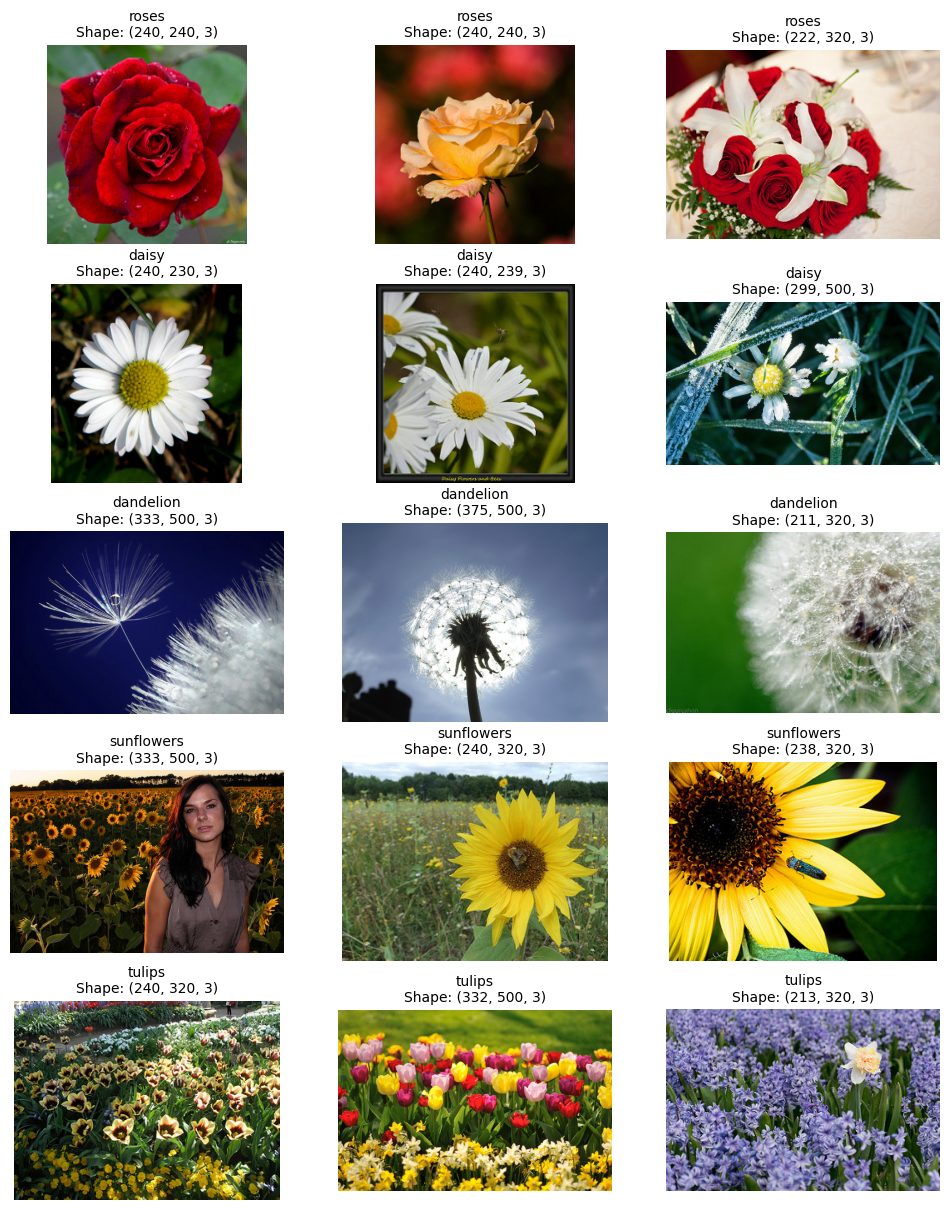

In [32]:
import matplotlib.pyplot as plt

# Creamos la figura con 5 filas (5 clases) y 3 columnas (3 imágenes)
fig, axes = plt.subplots(nrows = 5, ncols = 3, figsize = (12, 15))

for i, cl in enumerate(classes):
    path_clase = os.path.join(train_dir, cl)
    # Cogemos los nombres de los 3 primeros archivos
    archivos = os.listdir(path_clase)[:3]

    for j, nombre_archivo in enumerate(archivos):
        ruta_imagen = os.path.join(path_clase, nombre_archivo)
        # Leemos la imagen (convertimos el JPG a array de Numpy)
        img = plt.imread(ruta_imagen)

        ax = axes[i, j]
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(f"{cl}\nShape: {img.shape}", fontsize=10)

plt.show()

# c) Modelo 1: CNN básica (objetivo: accuracy_valid > 60%)


Implemente una red convolucional para resolver el problema de clasificación. Para ello se sugiere una CNN con 3 capas convolucionales + pooling con la siguiente estructura:

Bloque de procesamiento de imagen:
1.   32 kernels -> 64 kernels -> 96 kernels
2.   kernels de 3x3.
3.   Stride = 1 y padding = SI.
4.   Función de activación ReLU.
5.   Maxpooling de 2x2 con stride clásico de 2 pixeles.
6.   Igualamos el tamaño de todas las imágenes a 150 x 150.

Bloque de decisión:
7.   Capa densa de 512 neuronas.
8.   Capa densa de salida.

**Tarea 4: Define un modelo con la estructura anterior**



In [11]:
modelo_1 = keras.Sequential()

# BLOQUE DE PROCESAMIENTO DE IMAGEN
# Primera capa convolucional + pooling
modelo_1.add(keras.layers.Conv2D(filters = 32, # 32 kernels
                         kernel_size = (3, 3), # Kernels de 3 x 3
                         strides = (1, 1), # stride = 1
                         padding = 'same', # padding = SI
                         activation = 'relu', # Función de activación ReLU
                         name = 'Conv_1',
                         input_shape = (150, 150, 3))) # Las imágenes de entrada tienen tamaño 150 x 150 y son RGB

modelo_1.add(keras.layers.MaxPooling2D(pool_size = (2, 2), # Maxpooling de 2 x 2
                               strides = (2, 2), # stride = 2
                               name = 'Pool_1'))

# Segunda capa convolucional + pooling
modelo_1.add(keras.layers.Conv2D(filters = 64,
                         kernel_size = (3, 3),
                         strides = (1, 1),
                         padding = 'same',
                         activation = 'relu',
                         name = 'Conv_2'))

modelo_1.add(keras.layers.MaxPooling2D(pool_size = (2, 2),
                               strides = (2, 2),
                               name = 'Pool_2'))

# Tercera capa convolucional + pooling
modelo_1.add(keras.layers.Conv2D(filters = 96,
                         kernel_size = (3, 3),
                         strides = (1, 1),
                         padding = 'same',
                         activation = 'relu',
                         name = 'Conv_3'))

modelo_1.add(keras.layers.MaxPooling2D(pool_size = (2, 2),
                               strides = (2, 2),
                               name = 'Pool_3'))

# BLOQUE DE DECISIÓN
# Aplanamos
modelo_1.add(keras.layers.Flatten(name = 'flatten'))

# Capa densa
modelo_1.add(keras.layers.Dense(units = 512, activation = 'relu', name = 'densa_1'))

# Capa densa de salida
# Utilizamos 5 neuronas y 'softmax' como función de activación para que la salida sean las probabilidades de que la flor de
# la imagen pertenezca a cada una de las 5 posibles clases.
modelo_1.add(keras.layers.Dense(units = 5, activation = 'softmax', name = 'densa_2'))

**Tarea 5: Indica el shape de la imagen antes y después de cada capa de la red. Explica cómo has obtenido dichos valores**

|Capa| Shape a la salida| #parámetros |
|:-|:-:|:-:|
|Conv_1|(150, 150, 32)|896
|Pool_1|(75, 75, 32)|0
|Conv_2|(75, 75, 64)|18496
|Pool_2|(37, 37, 64)|0
|Conv_3|(37, 37, 96)|55392
|Pool_3|(18, 18, 96)|0
|flatten|(31104)|0
|densa_1|(512)|15925760
|densa_2|(5)|2565

Hemos añadido Conv_3, Pool_3 y densa_2 porque aunque no vinieran inicialmente en la tabla, en el enunciado se indica que hay que escribir la información de cada capa de la red.

- **Conv_1:** Como tenemos 32 kernels (filters), obtenemos 32 outputs. Dado que stride = 1 y padding = sí, el tamaño de la convolución no cambia, así que como las imágenes son de 150 x 150, el shape que obtenemos a la salida de esta capa es (150, 150, 32).
- **Pool_1:** Dividimos el alto y el ancho por stride = 2, así que nos queda un shape de (75, 75, 32).
- **Conv_2:** Ahora tenemos 64 kernels y el tamaño de los datos que entran es de 75 x 75, por lo que, por un razonamiento similar al de Conv_1, la salida tiene shape (75, 75, 64).
- **Pool_2:** Volvemos a dividir el alto y el ancho por stride = 2 y en este caso, como el resultado tiene decimales, truncamos, obteniendo un shape de (37, 37, 64).
- **Conv_3:** Ahora tenemos 96 kernels con datos de entrada de 37 x 37. El resultado posee shape (37, 37, 96).
- **Pool_3:** Dividimos de nuevo por stride = 2 y volvemos a truncar. El resultado tiene un shape de (18, 18, 96).
- **flatten:** Al aplanar, conseguimos 18 · 18 · 96 = 31104 outputs.
- **densa_1:** Esta capa posee 512 neuronas, por lo que obtenemos 512 outputs.
- **densa_2:** Esta capa presenta 5 neuronas, así que tenemos 5 outputs.

Las capas de pooling no tienen parámetros, por lo que #parámetros en **Pool_1**, **Pool_2** y **Pool_3** es 0. Igual sucede con la capa **flatten**.

Para calcular #parámetros en las capas convolucionales podemos deducir la fórmula:

_#parámetros = (Ancho kernel · Alto kernel · Canales de entrada) · Nº kernels + 1 · Nº kernels_

Entonces...
- En **Conv_1**, como las imágenes RGB tienen 3 canales de entrada, dado que se aplican 32 kernels de tamaño 3 x 3, #parámetros = (3 · 3 · 3) · 32 + 1 · 32 = 896
- En **Conv_2** ahora tenemos 32 canales de entrada y 64 kernels 3 x 3, luego #parámetros = (3 · 3 · 32) · 64 + 1 · 64 = 18496
- En **Conv_3** se presentan 64 canales de entrada y 96 kernels 3 x 3, así que #parámetros = (3 · 3 · 64) · 96 + 1 · 96 = 55392

Por otro lado, para calcular #parámetros en las capas densas, se tiene que:

_#parámetros = (Neuronas de entrada + 1) · Neuronas de salida_

- En **densa_1**, #parámetros = (31104 + 1) · 512 = 15925760
- En **densa_2**, #parámetros = (512 + 1) · 5 = 2565


**Tarea 6: Compara el resultado con un summary() del modelo**


In [12]:
modelo_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Conv_1 (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool_1 (MaxPooling2D)           │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_2 (Conv2D)                 │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool_2 (MaxPooling2D)           │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_3 (Conv2D)                 │ (None, 37, 37, 96)     │        55,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool_3 (MaxPooling2D)           │ (None, 18, 18, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 31104)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densa_1 (Dense)                 │ (None, 512)            │    15,925,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densa_2 (Dense)                 │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,003,109 (61.05 MB)

 Trainable params: 16,003,109 (61.05 MB)

 Non-trainable params: 0 (0.00 B)

**Tarea 7: Entrena el modelo de manera que obtenga un accuracy (sobre el conjunto de validación) > 60%.**

* Utilice el optimizador que considere más adecuado.
*   Recuerda que si no se realiza conversión a One-Hot de la etiqueta a predecir, debes utilizar como función de error `SparseCategoricalCrossentropy` (este es el procedimiento que hemos usado en clase).
*   Considera un learning rate en el entorno de 0.001.
*   En el caso de los generators utiliza `class_mode='sparse'`.
*   Puedes utilizar p.e. un `batch_size = 100`.

In [13]:
# COMPILACIÓN DEL MODELO

# Usamos el optimizador Adam. Hemos tomado esta decisión por ser el que hemos utilizado en clase para entrenar un modelo de clasificación de imágenes.
optim = keras.optimizers.Adam(learning_rate = 0.001)

modelo_1.compile(loss = 'sparse_categorical_crossentropy',
                 optimizer = optim,
                 metrics = ['accuracy'])

In [14]:
# PREPROCESADO
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Reescalamos los píxeles de las imágenes al rango [0, 1].
train_datagen = ImageDataGenerator(rescale = 1./255)
val_datagen = ImageDataGenerator(rescale = 1./255)

# Creamos los generadores de tensores de las imágenes.
train_generator = train_datagen.flow_from_directory(
        train_dir, # Directorio con las imágenes
        target_size = (150, 150), # Hacemos que las imágenes tengan tamaño 150 x 150
        batch_size = 100, # Se procesan las imágenes en grupos de 100
        class_mode = 'sparse')

validation_generator = val_datagen.flow_from_directory(
        val_dir,
        target_size = (150, 150),
        batch_size = 100,
        class_mode = 'sparse')

Found 2935 images belonging to 5 classes.
Found 735 images belonging to 5 classes.


In [15]:
# ENTRENAMIENTO

# Como best-practice, utilizamos early stopping. De esta manera, el modelo monitoriza el entrenamiento y si detecta que el rendimiento
# mejora en los datos de entrenamiento pero empeora en los de validación, se detiene (frena el overfitting).
es_callback = keras.callbacks.EarlyStopping(patience = 4, # Antes de parar, el modelo se espera 4 epochs más para ver si la puntuación
                                                          # deja de empeorar
                                            restore_best_weights = True) # Una vez que el modelo se detiene, devuelve una red con los pesos con los
                                                                         # que obtuvo mejores resultados

history_1 = modelo_1.fit(
      train_generator,
      epochs = 10, # En principio tendremos 10 epochs, aunque podrán ser menos por el early stopping
      validation_data = validation_generator,
      callbacks = [es_callback],
      verbose = 2) # Ponemos esta opción para que se imprima una sola línea de texto por cada epoch

Epoch 1/10
30/30 - 23s - 779ms/step - accuracy: 0.3342 - loss: 1.6326 - val_accuracy: 0.5143 - val_loss: 1.1448
Epoch 2/10
30/30 - 7s - 244ms/step - accuracy: 0.5284 - loss: 1.1127 - val_accuracy: 0.5265 - val_loss: 1.2345
Epoch 3/10
30/30 - 8s - 271ms/step - accuracy: 0.6160 - loss: 0.9707 - val_accuracy: 0.6000 - val_loss: 0.9985
Epoch 4/10
30/30 - 8s - 272ms/step - accuracy: 0.6460 - loss: 0.8753 - val_accuracy: 0.6150 - val_loss: 0.9848
Epoch 5/10
30/30 - 7s - 247ms/step - accuracy: 0.7295 - loss: 0.7146 - val_accuracy: 0.6721 - val_loss: 0.8784
Epoch 6/10
30/30 - 8s - 273ms/step - accuracy: 0.7635 - loss: 0.6295 - val_accuracy: 0.6503 - val_loss: 0.9270
Epoch 7/10
30/30 - 10s - 342ms/step - accuracy: 0.8252 - loss: 0.4806 - val_accuracy: 0.6503 - val_loss: 0.9723
Epoch 8/10
30/30 - 7s - 250ms/step - accuracy: 0.8882 - loss: 0.3442 - val_accuracy: 0.6939 - val_loss: 1.0199
Epoch 9/10
30/30 - 8s - 269ms/step - accuracy: 0.9216 - loss: 0.2344 - val_accuracy: 0.6789 - val_loss: 1.0922

**Tarea 8: Muestra la evolución de la función de error (train y valid) durante el entrenamiento.Explica que problema presenta el modelo que hemos entrenado.**

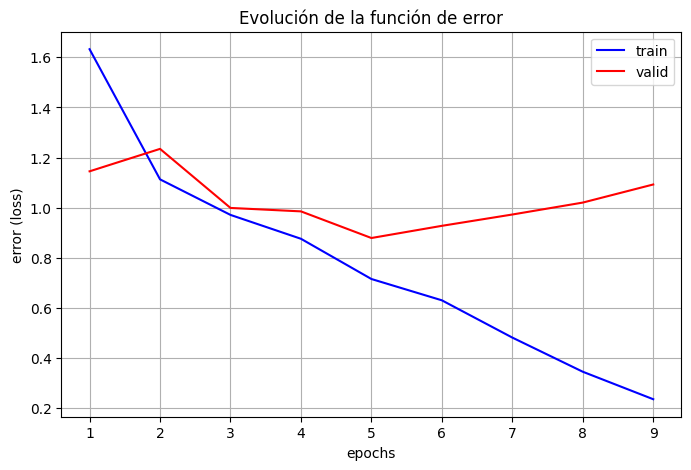

In [16]:
pd.DataFrame({'train': history_1.history['loss'],
              'valid': history_1.history['val_loss']},
             index = range(1, len(history_1.history['loss']) + 1)).plot(figsize = (8, 5), color = ['b', 'r'])

plt.grid(True)
plt.xlabel('epochs')
plt.ylabel('error (loss)')
plt.title('Evolución de la función de error');

Pese a haber utilizado early stopping, el problema principal que presenta este modelo es un claro overfitting.

Si observamos la gráfica de la función de error, podemos ver que durante los primeros epochs, tanto el error de entrenamiento (línea azul) como el de validación (línea roja) descienden a la vez. Sin embargo, se llega a un punto de inflexión donde el modelo empieza a memorizar los datos de entrenamiento (pues el error de train sigue descendiendo hacia 0), pero pierde por completo la capacidad de generalizar frente a datos nuevos, ya que el error de valid deja de disminuir, comenzando incluso a aumentar.

Nuestra red neuronal es muy compleja (tiene 16M de parámetros), así que tiene mucha capacidad de memoria para un dataset relativamente pequeño. El overfitting ocurre porque no hemos aplicado ninguna técnica de regularización para evitar que el modelo se aprenda de forma tan exacta las imágenes de las flores que hemos utilizado para el entrenamiento.

# d) Modelo 2: reducción del overfitting (objetivo: accuracy_valid > 70%)

Para mejorar el accuracy del modelo, vamos a incorporar las dos técnicas más habituales de reducción del overfitting:

    * drop-out
    * data augmentation
    

**Tarea 9: Explica en que consisten y qué utilidad tienen para nuestro problema**





El **drop-out** consiste en desactivar aleatoriamente un porcentaje de neuronas de una o varias capas del modelo durante cada paso (cada batch) del entrenamiento. Sirve para evitar que la red dependa de un camino demasiado específico para identificar a una flor, obligando a todas las neuronas a aprender características útiles por su cuenta. De esta forma, se tienen en cuenta más consideraciones a la hora de realizar la clasificación.

Por otro lado, el **data augmentation** consiste en aplicar transformaciones aleatorias (como giros, rotaciones, recortes, cambios de brillo, etc.) a las imágenes de entrenamiento antes de pasárselas a la red neuronal. De este modo, el modelo nunca ve exactamente la misma imagen en distintos epochs.
Como tenemos un dataset relativamente pequeño (unas 500-700 imágenes de train por clase), si utilizamos esta técnica multiplicaremos artificialmente el tamaño de nuestro conjunto de datos, lo que será muy beneficioso porque se podrá entrenar más al modelo. Además, obligaremos a la red a aprender las características realmente importantes a la hora de clasificar cada flor, ya que los detalles irrelevantes se verán modificados en cada epoch y por tanto, no serán aprendidos.

**Tarea 10: Construye un nuevo modelo 2 incorporando (en el modelo 1 anterior) el dropout adecuado**

In [17]:
modelo_2 = keras.Sequential()

# BLOQUE DE PROCESAMIENTO DE IMAGEN
# Primera capa convolucional + pooling
modelo_2.add(keras.layers.Conv2D(filters = 32,
                         kernel_size = (3, 3),
                         strides = (1, 1),
                         padding = 'same',
                         activation = 'relu',
                         name = 'Conv_1',
                         input_shape = (150, 150, 3)))

modelo_2.add(keras.layers.MaxPooling2D(pool_size = (2, 2),
                               strides = (2, 2),
                               name = 'Pool_1'))

# Segunda capa convolucional + pooling
modelo_2.add(keras.layers.Conv2D(filters = 64,
                         kernel_size = (3, 3),
                         strides = (1, 1),
                         padding = 'same',
                         activation = 'relu',
                         name = 'Conv_2'))

modelo_2.add(keras.layers.MaxPooling2D(pool_size = (2, 2),
                               strides = (2, 2),
                               name = 'Pool_2'))

# Tercera capa convolucional + pooling
modelo_2.add(keras.layers.Conv2D(filters = 96,
                         kernel_size = (3, 3),
                         strides = (1, 1),
                         padding = 'same',
                         activation = 'relu',
                         name = 'Conv_3'))

modelo_2.add(keras.layers.MaxPooling2D(pool_size = (2, 2),
                               strides = (2, 2),
                               name = 'Pool_3'))

# BLOQUE DE DECISIÓN
# Aplanamos
modelo_2.add(keras.layers.Flatten(name = 'flatten'))

# Capa densa
modelo_2.add(keras.layers.Dense(units = 512, activation = 'relu', name = 'densa_1'))

# Capa de drop-out
modelo_2.add(keras.layers.Dropout(0.5, name = 'dropout_1')) # Apagamos el 50% de las neuronas de la capa 'densa_1' aleatoriamente en cada batch.
                                                            # Hemos elegido esta capa porque al tener tantas neuronas, es la que más tiende a memorizar
                                                            # los datos

# Capa densa de salida
modelo_2.add(keras.layers.Dense(units = 5, activation = 'softmax', name = 'densa_2'))

modelo_2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Conv_1 (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool_1 (MaxPooling2D)           │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_2 (Conv2D)                 │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool_2 (MaxPooling2D)           │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_3 (Conv2D)                 │ (None, 37, 37, 96)     │        55,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool_3 (MaxPooling2D)           │ (None, 18, 18, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 31104)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densa_1 (Dense)                 │ (None, 512)            │    15,925,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densa_2 (Dense)                 │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,003,109 (61.05 MB)

 Trainable params: 16,003,109 (61.05 MB)

 Non-trainable params: 0 (0.00 B)

**Tarea 11: Explica que tipos de augmentation vas a considerar y que utilidad tienen en nuestro problema de clasificacion**

Vamos a considerar los siguientes tipos de augmentation:
- _Rotación_ (`rotation_range`): Una flor puede ser vista o fotografiada desde cualquier ángulo. Girar la imagen aleatoriamente ayuda a que la red no memorice su orientación original y por tanto, que no tenga en cuenta dicha característica para identificar otras flores.
- _Desplazamiento horizontal y vertical_ (`width_shift_range` y `height_shift_range`): En muchas de las fotografías del dataset, la flor no está perfectamente en el centro geométrico de la imagen. Al desplazar, obligamos al modelo a buscarla por todo el lienzo.
- _Volteo horizontal_ (`horizontal_flip`): La orientación de las flores es irrelevante (la flor sigue siendo la misma), así que voltear la foto nos da una imagen completamente nueva y válida para entrenar.
- _Zoom_ (`zoom_range`): En nuestro dataset tenemos fotografías tomadas muy de cerca y otras a mayor distancia. Aplicar un zoom aleatorio ayuda a la red a identificar la flor independientemente de su tamaño relativo en la foto.

**Tarea 12: Entrena el modelo de manera que obtenga un accuracy (sobre el conjunto de validación) > 70%.**

In [18]:
# COMPILACIÓN DEL MODELO

# Es necesario reiniciar el optimizador
optim = keras.optimizers.Adam(learning_rate = 0.001)

modelo_2.compile(loss = 'sparse_categorical_crossentropy',
                 optimizer = optim,
                 metrics = ['accuracy'])

In [19]:
# PREPROCESADO

# Volvemos a crear el generador de train, ahora aplicando data augmentation.
train_datagen_augmented = ImageDataGenerator(
    rescale = 1./255,
    rotation_range = 40, # Rotación aleatoria de hasta 40 grados
    width_shift_range = 0.2, # Desplazamiento horizontal aleatorio de hasta un 20%
    height_shift_range = 0.2, # Desplazamiento vertical aleatorio de hasta un 20%
    zoom_range = 0.2, # Zoom aleatorio de hasta un 20%
    horizontal_flip = True # Volteo horizontal aleatorio
)

train_generator_augmented = train_datagen_augmented.flow_from_directory(
    train_dir,
    target_size = (150, 150),
    batch_size = 100,
    class_mode = 'sparse'
)

Found 2935 images belonging to 5 classes.


In [20]:
# ENTRENAMIENTO

es_callback = keras.callbacks.EarlyStopping(patience = 6, # Al usar data augmentation, al principio a la red le cuesta más aprender, así que subimos
                                                          # patience a 6 para evitar que se detenga demasiado pronto.
                                            restore_best_weights = True)

history_2 = modelo_2.fit(
      train_generator_augmented,
      epochs = 20, # Aumentamos el número de epochs a 20 porque con las técnicas utilizadas debería haber menos overfitting y así podemos
                   # entrenar más el modelo.
      validation_data = validation_generator,
      callbacks = [es_callback],
      verbose = 2)

Epoch 1/20
30/30 - 29s - 977ms/step - accuracy: 0.3353 - loss: 1.6147 - val_accuracy: 0.4381 - val_loss: 1.3087
Epoch 2/20
30/30 - 22s - 749ms/step - accuracy: 0.4818 - loss: 1.2282 - val_accuracy: 0.5374 - val_loss: 1.1652
Epoch 3/20
30/30 - 22s - 748ms/step - accuracy: 0.5479 - loss: 1.1060 - val_accuracy: 0.6381 - val_loss: 0.9892
Epoch 4/20
30/30 - 22s - 741ms/step - accuracy: 0.5922 - loss: 1.0261 - val_accuracy: 0.6503 - val_loss: 1.0004
Epoch 5/20
30/30 - 22s - 717ms/step - accuracy: 0.6170 - loss: 0.9810 - val_accuracy: 0.6435 - val_loss: 0.9655
Epoch 6/20
30/30 - 23s - 751ms/step - accuracy: 0.6303 - loss: 0.9365 - val_accuracy: 0.6571 - val_loss: 0.9235
Epoch 7/20
30/30 - 23s - 753ms/step - accuracy: 0.6511 - loss: 0.8999 - val_accuracy: 0.6816 - val_loss: 0.8529
Epoch 8/20
30/30 - 23s - 750ms/step - accuracy: 0.6668 - loss: 0.8601 - val_accuracy: 0.6993 - val_loss: 0.8075
Epoch 9/20
30/30 - 21s - 711ms/step - accuracy: 0.6842 - loss: 0.8201 - val_accuracy: 0.6966 - val_loss:

**Tarea 13: Muestra la evolucion de la funcion de error durante el entrenamiento. Explica qué diferencias de comportamiento hay entre las gráficas del modelo 1 y el modelo 2**

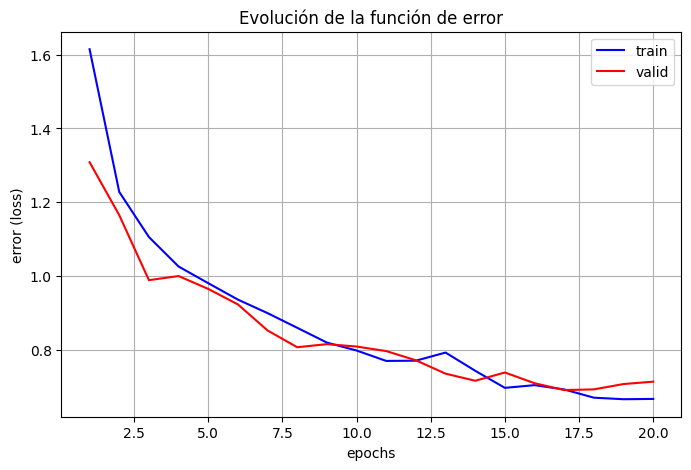

In [21]:
pd.DataFrame({'train': history_2.history['loss'],
              'valid': history_2.history['val_loss']},
             index = range(1, len(history_2.history['loss']) + 1)).plot(figsize = (8, 5), color = ['b', 'r'])

plt.grid(True)
plt.xlabel('epochs')
plt.ylabel('error (loss)')
plt.title('Evolución de la función de error');

Al observar las gráficas de aprendizaje del Modelo 2, podemos confirmar que las técnicas de regularización aplicadas han funcionado con éxito, solucionando el grave problema de overfitting que sufría el Modelo 1.

La diferencia clave que demuestra la mejora y que se puede ver en las gráficas es que en el Modelo 1, llegado a cierto punto, la línea de error de validación se separaba de la de entrenamiento y se disparaba hacia arriba rápidamente (se memorizaban los datos de train). Sin embargo, en este Modelo 2, ambas líneas descienden juntas de manera estable y progresiva, lo que significa que el modelo está aprendiendo patrones reales y generalizables.

Además, cuando hemos entrenado este último modelo hemos visto que se ha superado el 70% de accuracy y que en este caso, el early stopping ni siquiera ha tenido que intervenir.

# c) Modelo 3: Transfer Learning (objetivo: accuracy_valid > 88%)

En nuestro problema de clasificación de flores, el utilizar CNNs diseñadas y entrenadas por nosotros mismos, aparece una barrera en las proximidades del 75-77% de precisión del modelo (siempre sobre validación).

Para superar este escollo, el siguiente paso natural es la utilización de modelos preentrenados. Existe una gran variedad de ellos basados en redes CNNs clásicas, donde la principal diferencia es que acumulan más capas que nuestros modelos 1 y 2. Adicionalmente, en estos modelos se han ido incorporando diferentes propuestas para mejorar la arquitectura de la CNN.

En general, utilizando estos modelos convolucionales preentrenados podemos alcanzar accuracies próximos al 90%. Normalmente, estos modelos han sido previamente entrenados sobre datasets de gran tamaño y con gran número de categorías. P.e. en subconjuntos de Imagenet (14 millones de imagenes de 22K categorías).

Dado que estos modelos se entrenaron para resolver un problema "relativamente" parecido a nuestro problema de clasificación, parece razonable pensar que podemos aprovechar ese conocimiento capturado en la red para resolver nuestro problema de clasificación de flores.



Para elegir el modelo preentrenado que debe utilizar cada grupo, proceda del siguiente modo:
* Paso 1: sume los DNIs de los componentes del grupo (si el grupo tiene un sólo miembro, vaya directamente al paso 2). res = dni_1 + dn_2
* Paso 2: Aplique la siguiente operación al resultado anterior: res mod 6.
* Paso 3: Tome el modelo cuyo número asociado coincide con el resultado de la operación anterior.
* Paso 4: El porcentaje que aparece entre paréntesis junto al nombre del modelo es el accuracy (en validación) que deberías poder alcanzar sin dificultad utilizando el modelo. En todos los casos considera un input_shape = (224, 224, 3).

  0. Resnet50 (>90%)
  https://www.tensorflow.org/api_docs/python/tf/keras/applications/resnet50/ResNet50

  1. Resnet101 (>90%) input_shape = (224, 224, 3)
  https://www.tensorflow.org/api_docs/python/tf/keras/applications/resnet/ResNet101

  2. VGG16 (>90%) input_shape = (224, 224, 3)
  https://www.tensorflow.org/api_docs/python/tf/keras/applications/vgg16/VGG16

  3. VGG19 (>90%) input_shape = (224, 224, 3) https://www.tensorflow.org/api_docs/python/tf/keras/applications/vgg19/VGG19

  4. Xception (>88%) input_shape = (224, 224, 3) https://www.tensorflow.org/api_docs/python/tf/keras/applications/xception/Xception

  5. Inceptionv3 (>88%) input_shape = (224, 224, 3) https://www.tensorflow.org/api_docs/python/tf/keras/applications/inception_v3/InceptionV3

P.e. si los DNIs de los alumnos son: 12345678 y 23456781. La suma es 35802459. De donde 35802459 mod 6 = 3. Por tanto, tomaríamos el modelo VGG16.

Recuerda que puedes utilizar el siguiente post como referencia del uso de transfer learning: https://www.learndatasci.com/tutorials/hands-on-transfer-learning-keras/

**Tarea 14: Importa el modelo desde Tensorflow**

Dado que este modelo ha sido entrenado para clasificar entre 1.000 categorías, las capas densas finales del modelo no son útiles para nuestro problema de clasificación de 5 categorías (es lo que suele llamarse include_top = SI/NO). De manera que eliminamos lo que a veces se suele llamar el "top model". De este modo sólo nos quedamos con la parte que hace la funcionalidad de "procesamiento" de la imagen.

In [12]:
# 20098557 + 54179941 = 74278498
# 74278498 mod 6 = 4 -> Nuestro modelo es Xception

In [17]:
base_model = keras.applications.Xception(
    weights = 'imagenet', # Importamos el modelo con los pesos aprendidos por entrenarse con Imagenet
    include_top = False,
    input_shape = (224, 224, 3)
)

**Tarea 15: Personalizar el bloque de decisión**  
Añadimos una capa de flatten y tres nuevas capas densas especificas para nuestro problema con dimensiones 4096, 1072 y la que necesite la capa de salida (con sus correspondientes drop-outs).

In [18]:
modelo_3 = keras.Sequential([
    base_model,
    keras.layers.Flatten(name = 'flatten'),
    keras.layers.Dense(units = 4096, activation = 'relu', name = 'densa_1'),
    keras.layers.Dropout(0.5, name = 'dropout_1'),
    keras.layers.Dense(units = 1072, activation = 'relu', name = 'densa_2'),
    keras.layers.Dropout(0.5, name = 'dropout_2'),
    keras.layers.Dense(units = 5, activation = 'softmax', name = 'densa_3') # En nuestro caso necesitamos 5 outputs
])

modelo_3.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ xception (Functional)           │ (None, 7, 7, 2048)     │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densa_1 (Dense)                 │ (None, 4096)           │   411,045,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densa_2 (Dense)                 │ (None, 1072)           │     4,391,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densa_3 (Dense)                 │ (None, 5)              │         5,365 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 436,304,717 (1.63 GB)

 Trainable params: 436,250,189 (1.63 GB)

 Non-trainable params: 54,528 (213.00 KB)

**Tarea 16: Congelar los pesos que no se vayan a entrenar**

Previo a hacer el denominado `Fine-Tuning` del modelo, indicaremos a Tensorflow que únicamente debe entrenar:

   * Las dos últimas capas convolucionales de la red preentrenada, de las que realizaremos un ajuste fino de los pesos.
   * Las tres capas densas que hemos incluido nuevas.

In [19]:
# Para ver cómo se llaman las dos últimas capas convolucionales de la red preentrenada, imprimimos la información de las últimas 10 capas.
for capa in base_model.layers[-10:]:
    print(f"Nombre: {capa.name} --> Tipo: {capa.__class__.__name__}")

Nombre: conv2d_7 --> Tipo: Conv2D
Nombre: block13_pool --> Tipo: MaxPooling2D
Nombre: batch_normalization_7 --> Tipo: BatchNormalization
Nombre: add_23 --> Tipo: Add
Nombre: block14_sepconv1 --> Tipo: SeparableConv2D
Nombre: block14_sepconv1_bn --> Tipo: BatchNormalization
Nombre: block14_sepconv1_act --> Tipo: Activation
Nombre: block14_sepconv2 --> Tipo: SeparableConv2D
Nombre: block14_sepconv2_bn --> Tipo: BatchNormalization
Nombre: block14_sepconv2_act --> Tipo: Activation


In [20]:
# Entrenamos las tres capas densas que hemos incluido en el modelo: 'densa_1', 'densa_2' y 'densa_3'.
for layer in modelo_3.layers:
    if layer.name == 'densa_1' or layer.name == 'densa_2' or layer.name == 'densa_3' or layer.name == 'xception':
        # (Es necesario poner xception a True para que las capas convolucionales del modelo base que nos interesan puedan entrenarse)
        layer.trainable = True
    else:
        layer.trainable = False

# Entrenamos también 'block14_sepconv1' y 'block14_sepconv2'.
for layer in base_model.layers:
    if layer.name == 'block14_sepconv1' or layer.name == 'block14_sepconv2':
        layer.trainable = True # Activamos sólo el entrenamiento de las capas que queremos
    else:
        layer.trainable = False

In [21]:
print("Últimas capas de Xception:")
for layer in base_model.layers[-6:]: # Imprimimos solo las últimas 6 para no saturar la pantalla
    print(f" - {layer.name}: Entrenable = {layer.trainable}")

print("\nCapas de modelo_3:")
for layer in modelo_3.layers:
    print(f" - {layer.name}: Entrenable = {layer.trainable}")

Últimas capas de Xception:
 - block14_sepconv1: Entrenable = True
 - block14_sepconv1_bn: Entrenable = False
 - block14_sepconv1_act: Entrenable = False
 - block14_sepconv2: Entrenable = True
 - block14_sepconv2_bn: Entrenable = False
 - block14_sepconv2_act: Entrenable = False

Capas de modelo_3:
 - xception: Entrenable = True
 - flatten: Entrenable = False
 - densa_1: Entrenable = True
 - dropout_1: Entrenable = False
 - densa_2: Entrenable = True
 - dropout_2: Entrenable = False
 - densa_3: Entrenable = True


**Tarea 17: Crear los datagenerators oportunos**

Para ello:
> * Utiliza Data augmentation.  
> * Las imágenes tienen que ser preprocesadas igual que cuando se entrenó el modelo pre.entrenado original. Para ello se utiliza el parámetro `preprocessing_function=preprocess_input` (preprocess_input importado desde `keras.applications.xxxxxx` en ambos generators (train y valid). Por tanto, no hay que indicarle `rescale`. En caso de ser necesario, se encargará `preprocess_input`.  
> * Dado que estamos reutilizando un modelo que no "es nuestro", deberemos ceñirnos al tamaño de imagen que permite la red a la entrada. Recuerda que debe ser: 224x224.

In [28]:
train_datagen_augmented_tl = ImageDataGenerator(
    preprocessing_function = keras.applications.xception.preprocess_input,
    rotation_range = 40,
    width_shift_range = 0.2,
    height_shift_range = 0.2,
    zoom_range = 0.2,
    horizontal_flip = True
)

val_datagen_tl = ImageDataGenerator(preprocessing_function = keras.applications.xception.preprocess_input)


train_generator_augmented_tl = train_datagen_augmented_tl.flow_from_directory(
    train_dir,
    target_size = (224, 224),
    batch_size = 100,
    class_mode = 'sparse'
)

validation_generator_tl = val_datagen_tl.flow_from_directory(
    val_dir,
    target_size = (224, 224),
    batch_size = 100,
    class_mode = 'sparse')

Found 2935 images belonging to 5 classes.
Found 735 images belonging to 5 classes.


**Tarea 18: Haz el fine-tuning del modelo con el objetivo de alcanzar un accuracy (sobre el conjunto de validación > 88%).**

A la hora de entrenar un modelo pretrained es típico bajar el learning rate respecto al que utilizaríamos para un modelo nuestro desde cero.

In [29]:
optim = keras.optimizers.Adam(learning_rate = 0.0001) # Hemos bajado el learning rate a 0.0001

modelo_3.compile(
    loss = 'sparse_categorical_crossentropy',
    optimizer = optim,
    metrics = ['accuracy']
)

es_callback = keras.callbacks.EarlyStopping(patience = 6,
                                            restore_best_weights = True)

history_3 = modelo_3.fit(
      train_generator_augmented_tl,
      epochs = 30,
      validation_data = validation_generator_tl,
      callbacks = [es_callback],
      verbose = 2)

Epoch 1/30
30/30 - 142s - 5s/step - accuracy: 0.6773 - loss: 1.0859 - val_accuracy: 0.8490 - val_loss: 0.4131
Epoch 2/30
30/30 - 52s - 2s/step - accuracy: 0.8334 - loss: 0.4897 - val_accuracy: 0.8599 - val_loss: 0.3621
Epoch 3/30
30/30 - 52s - 2s/step - accuracy: 0.8753 - loss: 0.3622 - val_accuracy: 0.8694 - val_loss: 0.3496
Epoch 4/30
30/30 - 53s - 2s/step - accuracy: 0.8923 - loss: 0.2902 - val_accuracy: 0.8925 - val_loss: 0.3053
Epoch 5/30
30/30 - 53s - 2s/step - accuracy: 0.9155 - loss: 0.2524 - val_accuracy: 0.9007 - val_loss: 0.2887
Epoch 6/30
30/30 - 50s - 2s/step - accuracy: 0.9302 - loss: 0.2072 - val_accuracy: 0.8939 - val_loss: 0.3106
Epoch 7/30
30/30 - 50s - 2s/step - accuracy: 0.9298 - loss: 0.1928 - val_accuracy: 0.8884 - val_loss: 0.3420
Epoch 8/30
30/30 - 52s - 2s/step - accuracy: 0.9390 - loss: 0.1698 - val_accuracy: 0.9007 - val_loss: 0.3247
Epoch 9/30
30/30 - 51s - 2s/step - accuracy: 0.9482 - loss: 0.1473 - val_accuracy: 0.9048 - val_loss: 0.3144
Epoch 10/30
30/30 